# Initail Setup

In [1]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from one.api import ONE
from brainbox.io.one import SpikeSortingLoader, SessionLoader
from iblatlas.regions import BrainRegions
from iblatlas.plots import plot_scalar_on_slice
from iblatlas.atlas import AllenAtlas
from iblatlas.flatmaps import FlatMap
from iblatlas.plots import plot_swanson_vector
from iblatlas.plots import plot_scalar_on_flatmap
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
from scipy import stats
from scipy.signal import butter, filtfilt
import pickle
import matplotlib as mpl
from brainbox.ephys_plots import image_fr_plot
from iblutil.numerical import bincount2D

In [8]:
# Candidate sessions:

# subject = "UCLA_037"
# eid = "bda2faf5-9563-4940-a80f-ce444259e47b"
# pid = "29418b18-4db6-436f-a85e-b0f1d38d2e62"

In [2]:
# Define Constants / Configuration
CONFIG = {
    'REVISION': '2024-05-06', 
    'TASK_EXCLUDE_WINDOW_PRE': 0.2, 
    'TASK_EXCLUDE_WINDOW_POST': 0.5,
    'LP_FILTER_HZ': 20,
    'MAX_SESSIONS_TO_PROCESS': None, 
    'CCG_BIN_SIZE': 0.001, 
    'CCG_WINDOW_SIZE': 0.2,
    'COUPLING_METHOD': 'sta', # 'correlation' or 'sta'
}

In [3]:
# Define and create project paths
base_path = Path(r"C:/Users/Experiment/Documents/Amirreza/SeqProject2026")
path_data = base_path / "data"
path_fig = base_path / "results" / "figures"
path_data_processed = path_data / "processed"
ibl_cache = path_data / 'raw'

# Create directories
for p in [ibl_cache, path_fig, path_data_processed]:
    p.mkdir(exist_ok=True, parents=True)

print(f"Directories ready. Cache: {ibl_cache}")

# Setup the ONE API with custom cache directory
try:
    one = ONE(base_url='https://openalyx.internationalbrainlab.org', password='international', silent=True, cache_dir=ibl_cache)
    print("ONE API initialized.")
except Exception as e:
    print(f"Error initializing ONE: {e}")

# Setup AllenAtlas
ba = AllenAtlas()

Directories ready. Cache: C:\Users\Experiment\Documents\Amirreza\SeqProject2026\data\raw
ONE API initialized.


# Session Selection, Download and Load

In [4]:
tag = '2025_Q3_IBL_et_al_BWM' # 'RepeatedSite'
brain_acronym = 'VISp'

# query sessions endpoint
sessions = one.search(tag=tag, atlas_acronym=brain_acronym, query_type='remote')
print(f'No. of detected sessions: {len(sessions)}')

# query insertions endpoint
insertions = one.search_insertions(tag=tag, atlas_acronym=brain_acronym)
print(f'No. of detected insertions: {len(insertions)}')

No. of detected sessions: 62
No. of detected insertions: 67


In [5]:
# Define the Probe Insertion ID (PID)
pid = "c9664185-d3fd-4e0e-89cf-77c402038938"
print(f"\nProcessing PID: {pid}")

# Initialize SpikeSortingLoader
ssl = SpikeSortingLoader(pid=pid, one=one, atlas=ba)
print(f"Session ID (EID): {ssl.eid}")
print(f"Probe Name: {ssl.pname}")

# Load Spiking Neural Data (Spikes, Clusters, Channels)
# load_spike_sorting() downloads and loads the data efficiently
spikes, clusters, channels = ssl.load_spike_sorting()

# IMPORTANT: Merge clusters with channel data to get brain region acronyms and coordinates
clusters = ssl.merge_clusters(spikes, clusters, channels)

print(f"Spikes loaded: {spikes.times.shape[0]} spikes")
if 'acronym' in clusters:
    print(f"Cluster regions found: {set(clusters.acronym)}")

# Load Trial Data using SessionLoader
sl = SessionLoader(eid=ssl.eid, one=one)
sl.load_trials()
print(f"Trials loaded. Found keys: {list(sl.trials.keys())}")
sl.load_wheel()
print(f"Wheel data loaded. Found keys: {list(sl.wheel.keys())}")
sl.load_pose(views=['left', 'right'])
print(f"Pose data loaded. Found keys: {list(sl.pose.keys())}")

# Initialize containers for pupil data
pupil_features = None
pupil_times = None
try:
    print("Loading leftCamera data (features and times)...")
    # Explicitly load camera object using ONE as per IBL documentation
    # This downloads _ibl_leftCamera.features.pqt and _ibl_leftCamera.times.npy
    # We assume 'sl' (SessionLoader) is defined in the environment
    left_camera = sl.one.load_object(sl.eid, 'leftCamera', collection='alf')
    
    # Check if we have the necessary attributes
    if hasattr(left_camera, 'features') and hasattr(left_camera, 'times'):
        pupil_features = left_camera.features
        pupil_times = left_camera.times
        print("Camera data loaded successfully.")
    else:
        print("Camera object loaded but 'features' or 'times' attribute missing.")

except Exception as e:
    print(f"Could not load pupil data: {e}")


Processing PID: c9664185-d3fd-4e0e-89cf-77c402038938
Session ID (EID): e349a2e7-50a3-47ca-bc45-20d1899854ec
Probe Name: probe01


c:\Users\Experiment\anaconda3\envs\Seq2026\Lib\site-packages\one\util.py:414: ALFWarning: No default revision for dataset alf/probe01/pykilosort/#2024-03-12#/clusters.metrics.pqt; using most recent
  warnings.warn(


Spikes loaded: 28721702 spikes
Cluster regions found: {'VISp6a', 'ENTm2', 'VISp5', 'VISpl6a', 'void', 'HPF', 'ENTm3', 'ENTm1', 'ENTm5', 'ec', 'VISp1', 'VISp4', 'VISp2/3'}


c:\Users\Experiment\anaconda3\envs\Seq2026\Lib\site-packages\one\util.py:436: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


Trials loaded. Found keys: ['goCueTrigger_times', 'intervals_bpod_0', 'intervals_bpod_1', 'quiescencePeriod', 'stimOffTrigger_times', 'stimOff_times', 'stimOnTrigger_times', 'goCue_times', 'response_times', 'choice', 'stimOn_times', 'contrastLeft', 'contrastRight', 'probabilityLeft', 'feedback_times', 'feedbackType', 'rewardVolume', 'firstMovement_times', 'intervals_0', 'intervals_1']
Wheel data loaded. Found keys: ['times', 'position', 'velocity', 'acceleration']


c:\Users\Experiment\anaconda3\envs\Seq2026\Lib\site-packages\one\util.py:436: ALFWarning: Multiple revisions: "", "2023-04-20"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


Pose data loaded. Found keys: ['leftCamera', 'rightCamera']
Loading leftCamera data (features and times)...


c:\Users\Experiment\anaconda3\envs\Seq2026\Lib\site-packages\one\util.py:436: ALFWarning: Multiple revisions: "", "2025-06-04", "2025-05-31"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


Camera data loaded successfully.


# Behavioural Data

In [6]:
reaction_time = sl.trials['response_times'] - sl.trials['stimOn_times']

correct_trial_idx = sl.trials['feedbackType'] == 1
incorrect_trial_idx = sl.trials['feedbackType'] == -1
correct_reaction_time = np.mean(reaction_time[correct_trial_idx])
incorrect_reaction_time = np.mean(reaction_time[incorrect_trial_idx])

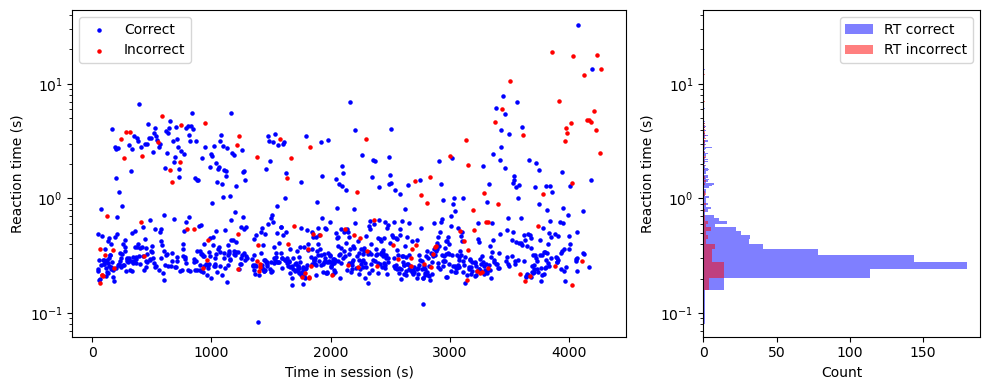

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios': [2, 1]})  # Adjust figsize as needed

# Scatter plot on the left (ax1)
ax1.scatter(sl.trials['stimOn_times'][correct_trial_idx], reaction_time[correct_trial_idx], c='blue', s=5, label='Correct')
ax1.scatter(sl.trials['stimOn_times'][incorrect_trial_idx], reaction_time[incorrect_trial_idx], c='red', s=5, label='Incorrect')
ax1.set_yscale("log")
ax1.set_xlabel('Time in session (s)')
ax1.set_ylabel('Reaction time (s)')
ax1.legend()

# Histogram on the right (ax2)
ax2.hist(reaction_time[correct_trial_idx], bins=np.linspace(0, 20, 500), color='blue', alpha=0.5, label='RT correct', orientation='horizontal')
ax2.hist(reaction_time[incorrect_trial_idx], bins=np.linspace(0, 20, 500), color='red', alpha=0.5, label='RT incorrect', orientation='horizontal')
ax2.legend()
ax2.set_xlabel('Count')
ax2.set_ylabel('Reaction time (s)')
ax2.set_yscale("log")
ax2.set_ylim(ax1.get_ylim())  # Sync y-axis limits with scatter plot

plt.tight_layout()  # Adjust spacing between subplots
#To see the output, run the code.

# Single Trial Raster Plots

In [8]:
# Update CONFIG with Raster Plot constants
CONFIG.update({
    'RASTER_TRIAL_IDX': 65,          # The specific trial index to plot
    'RASTER_WINDOW_PRE': 1,           # Seconds before Stim On
    'RASTER_WINDOW_POST': 2,          # Seconds after Feedback
    'RASTER_ONLY_GOOD_UNITS': True,   # Set to False to plot ALL neurons
    'RASTER_ALIGN_TO_STIM_ON': True,  # Set True to make Stim On = 0s, False for Session Time
})


# Flag to save the figure (Standalone variable, not in CONFIG)
SAVE_FIGURE = True

Pupil data found in window: 317 frames.
Figure saved to: C:\Users\Experiment\Documents\Amirreza\SeqProject2026\results\figures\c9664185-d3fd-4e0e-89cf-77c402038938_65_Raster.png


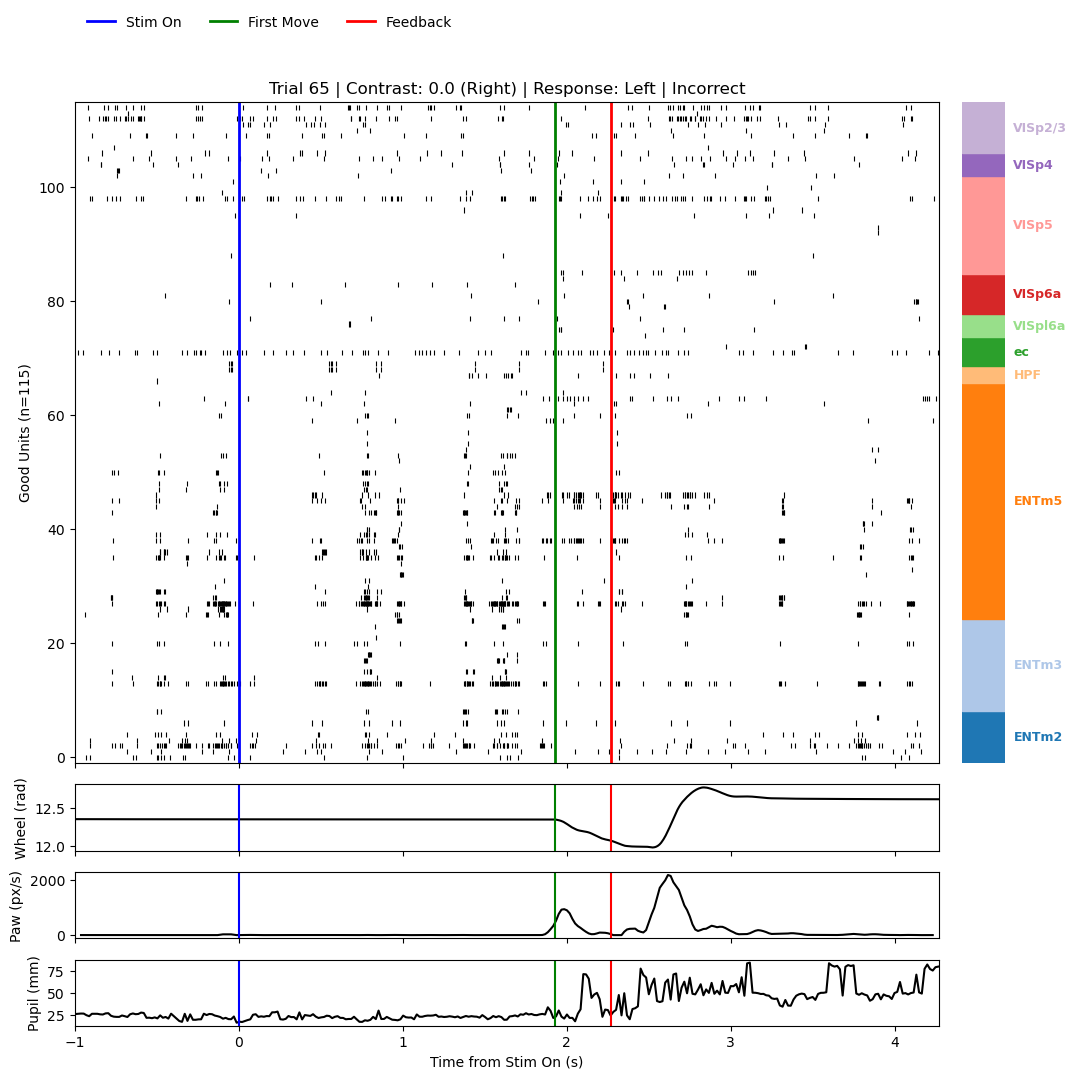

In [9]:
trial_idx = CONFIG['RASTER_TRIAL_IDX']

# Ensure 'sl' (SessionLoader) is defined in your environment
t_stim_on = sl.trials['stimOn_times'][trial_idx]
t_first_move = sl.trials['firstMovement_times'][trial_idx]
t_feedback = sl.trials['feedback_times'][trial_idx]

# Define the absolute time window for data filtering
t_start = t_stim_on - CONFIG['RASTER_WINDOW_PRE']
t_end = t_feedback + CONFIG['RASTER_WINDOW_POST']

# Determine Alignment Offset
if CONFIG['RASTER_ALIGN_TO_STIM_ON']:
    t_offset = t_stim_on
    xlabel_text = 'Time from Stim On (s)'
else:
    t_offset = 0
    xlabel_text = 'Time in session (s)'

# --- Retrieve Trial Metadata for Title ---
# Handle contrast (check for NaN to determine side)
cont_l = sl.trials['contrastLeft'][trial_idx]
cont_r = sl.trials['contrastRight'][trial_idx]

if not np.isnan(cont_l):
    contrast_val = cont_l
    stim_side = 'Left'
elif not np.isnan(cont_r):
    contrast_val = cont_r
    stim_side = 'Right'
else:
    contrast_val = 0
    stim_side = 'Zero'

# Handle Choice (-1: Right, 1: Left, 0: NoGo)
choice_map = {1: 'Left', -1: 'Right', 0: 'NoGo'}
choice_val = sl.trials['choice'][trial_idx]
response_str = choice_map.get(choice_val, str(choice_val))

# Handle Feedback (1: Correct, -1: Incorrect)
fb_val = sl.trials['feedbackType'][trial_idx]
outcome_str = 'Correct' if fb_val == 1 else 'Incorrect'

plot_title = f"Trial {trial_idx} | Contrast: {contrast_val} ({stim_side}) | Response: {response_str} | {outcome_str}"


# 2. Process Spike Data
# Select units based on configuration
if CONFIG['RASTER_ONLY_GOOD_UNITS']:
    # Filter for "good" clusters only (label == 1)
    target_indices = np.where(clusters.label == 1)[0]
    ylabel_text = f'Good Units (n={len(target_indices)})'
else:
    # Use all clusters
    target_indices = np.arange(len(clusters.label))
    ylabel_text = f'All Units (n={len(target_indices)})'

# Create a DataFrame for easier sorting/grouping
df_units = pd.DataFrame({
    'id': target_indices,
    'acronym': clusters.acronym[target_indices],
    'depth': clusters.depths[target_indices]
})

# Sort by depth ASCENDING (Deep -> Surface)
df_units = df_units.sort_values(by='depth', ascending=True).reset_index(drop=True)

# Map acronyms to colors for the sidebar
unique_regions = df_units['acronym'].unique()
region_colors = {reg: plt.cm.tab20(i % 20) for i, reg in enumerate(unique_regions)}
region_colors['void'] = 'black'

# Filter spikes for the time window GLOBALLY first (using absolute times)
mask_window = (spikes.times >= t_start) & (spikes.times <= t_end)
window_spike_times = spikes.times[mask_window]
window_spike_clusters = spikes.clusters[mask_window]

# 3. Process Behavioral Data
# --- Wheel Data ---
mask_wheel = (sl.wheel['times'] >= t_start) & (sl.wheel['times'] <= t_end)
wheel_t = sl.wheel['times'][mask_wheel]
wheel_pos = sl.wheel['position'][mask_wheel]

# --- Paw Speed Data ---
pose_t = None
paw_speed = None
if hasattr(sl, 'pose') and 'leftCamera' in sl.pose:
    pose_df = sl.pose['leftCamera']
    if 'times' in pose_df.columns:
        pose_timestamps = pose_df['times'].values
    else:
        pose_timestamps = pose_df.index.values

    mask_pose = (pose_timestamps >= t_start) & (pose_timestamps <= t_end)
    pose_t = pose_timestamps[mask_pose]
    
    # Calculate Speed
    paw_key = 'paw_r' if 'paw_r_x' in pose_df.columns else 'paw_l'
    if f'{paw_key}_x' in pose_df.columns:
        dx = np.gradient(pose_df[f'{paw_key}_x'].values[mask_pose])
        dy = np.gradient(pose_df[f'{paw_key}_y'].values[mask_pose])
        dt = np.gradient(pose_t)
        dt[dt == 0] = np.nan
        speed_raw = np.sqrt(dx**2 + dy**2) / dt
        paw_speed = pd.Series(speed_raw).fillna(0).rolling(window=5, center=True).mean().values

# --- Pupil Diameter Data ---
pupil_t = None
pupil_diam = None

if pupil_features is not None and pupil_times is not None:
    # Identify the correct diameter column
    diam_col = 'pupilDiameter_raw'
    
    if diam_col in pupil_features.columns:
        # Handle potential length mismatch (though unlikely in valid datasets)
        n_frames = min(len(pupil_times), len(pupil_features))
        
        # Slice valid data
        pt = pupil_times[:n_frames]
        pd_vals = pupil_features[diam_col].values[:n_frames]
        
        # Filter for the trial window
        mask_pupil = (pt >= t_start) & (pt <= t_end)
        pupil_t = pt[mask_pupil]
        pupil_diam = pd_vals[mask_pupil]
        print(f"Pupil data found in window: {len(pupil_t)} frames.")

# 4. Generate Plot
fig = plt.figure(figsize=(12, 12)) # Increased height for extra plot
# Adjusted height_ratios to make behavioral plots smaller [Raster, Wheel, Paw, Pupil]
gs = gridspec.GridSpec(4, 2, width_ratios=[20, 1], height_ratios=[10, 1, 1, 1], wspace=0.05, hspace=0.1)

# -- Raster Plot (Top Left) --
ax_raster = fig.add_subplot(gs[0, 0])

# Iterate through sorted units and plot using vlines (adjusting for offset)
for y_idx, row in df_units.iterrows():
    unit_spike_times = window_spike_times[window_spike_clusters == row['id']]
    if len(unit_spike_times) > 0:
        # Subtract offset to align relative to stim on if requested
        ax_raster.vlines(unit_spike_times - t_offset, y_idx - 0.45, y_idx + 0.45, color='k', linewidth=0.8)

# Events (Adjusted for offset)
for ax in [ax_raster]:
    ax.axvline(t_stim_on - t_offset, color='blue', linestyle='-', linewidth=2, label='Stim On')
    ax.axvline(t_first_move - t_offset, color='green', linestyle='-', linewidth=2, label='First Move')
    ax.axvline(t_feedback - t_offset, color='red', linestyle='-', linewidth=2, label='Feedback')

# Set Limits relative to offset
ax_raster.set_xlim(t_start - t_offset, t_end - t_offset)
ax_raster.set_ylim(-1, len(df_units))
ax_raster.set_ylabel(ylabel_text)
ax_raster.set_title(plot_title)
# Hide x-axis labels for raster
ax_raster.tick_params(labelbottom=False)

# -- Region Color Bar (Top Right) --
ax_regions = fig.add_subplot(gs[0, 1])
y_min = 0
for acronym, group in df_units.groupby('acronym', sort=False):
    count = len(group)
    color = region_colors.get(acronym, 'gray')
    ax_regions.add_patch(plt.Rectangle((0, y_min), 1, count, color=color))
    ax_regions.text(1.2, y_min + count/2, acronym, va='center', fontsize=9, color=color, fontweight='bold')
    y_min += count

ax_regions.set_ylim(0, len(df_units))
ax_regions.axis('off')

# -- Wheel Position (2nd Row) --
ax_wheel = fig.add_subplot(gs[1, 0], sharex=ax_raster)
ax_wheel.plot(wheel_t - t_offset, wheel_pos, color='black')
ax_wheel.set_ylabel('Wheel (rad)')
ax_wheel.axvline(t_stim_on - t_offset, color='blue', linewidth=1.5)
ax_wheel.axvline(t_first_move - t_offset, color='green', linewidth=1.5)
ax_wheel.axvline(t_feedback - t_offset, color='red', linewidth=1.5)
ax_wheel.tick_params(labelbottom=False)

# -- Paw Speed (3rd Row) --
ax_paw = fig.add_subplot(gs[2, 0], sharex=ax_raster)
if paw_speed is not None:
    ax_paw.plot(pose_t - t_offset, paw_speed, color='black')
else:
    ax_paw.text(0.5, 0.5, "Paw data not available", ha='center', transform=ax_paw.transAxes)

ax_paw.set_ylabel('Paw (px/s)')
ax_paw.axvline(t_stim_on - t_offset, color='blue', linewidth=1.5)
ax_paw.axvline(t_first_move - t_offset, color='green', linewidth=1.5)
ax_paw.axvline(t_feedback - t_offset, color='red', linewidth=1.5)
ax_paw.tick_params(labelbottom=False)

# -- Pupil Diameter (4th Row) --
ax_pupil = fig.add_subplot(gs[3, 0], sharex=ax_raster)
if pupil_diam is not None:
    ax_pupil.plot(pupil_t - t_offset, pupil_diam, color='black')
else:
    ax_pupil.text(0.5, 0.5, "Pupil data not available", ha='center', transform=ax_pupil.transAxes)

ax_pupil.set_ylabel('Pupil (mm)')
ax_pupil.set_xlabel(xlabel_text)
ax_pupil.axvline(t_stim_on - t_offset, color='blue', linewidth=1.5)
ax_pupil.axvline(t_first_move - t_offset, color='green', linewidth=1.5)
ax_pupil.axvline(t_feedback - t_offset, color='red', linewidth=1.5)
ax_pupil.tick_params(labelbottom=True)

# Legend
lines = [
    plt.Line2D([0], [0], color='blue', linewidth=2),
    plt.Line2D([0], [0], color='green', linewidth=2),
    plt.Line2D([0], [0], color='red', linewidth=2)
]
ax_raster.legend(lines, ['Stim On', 'First Move', 'Feedback'], loc='upper left', frameon=False, bbox_to_anchor=(0, 1.15), ncol=3)

# Save the figure if requested
if SAVE_FIGURE:
    # Ensure 'pid' and 'path_fig' are defined in the environment
    # Filename format: PID_Trial ID_Raster
    filename = f"{pid}_{trial_idx}_Raster.png"
    save_path = path_fig / filename
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Figure saved to: {save_path}")

plt.show()

# Single Neuron PSTH

Processing 1022 trials...
Found 979 clusters.
Computed delays for 979 neurons.
Filtered to 74 good, responsive units.


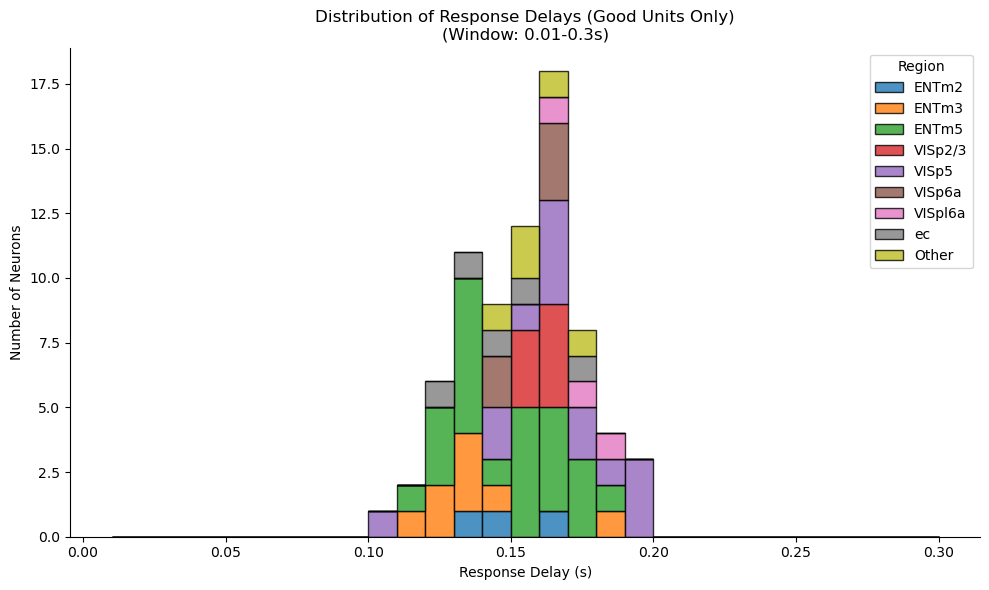


Summary Statistics by Region:
             count      mean       std
plot_region                           
ENTm2          3.0  0.147266  0.012191
ENTm3          8.0  0.137238  0.019459
ENTm5         24.0  0.149001  0.019418
Other          5.0  0.159080  0.013144
VISp2/3        7.0  0.160230  0.007578
VISp5         14.0  0.166275  0.023763
VISp6a         5.0  0.156443  0.010186
VISpl6a        3.0  0.176817  0.008613
ec             5.0  0.146377  0.020477


In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter1d

# ==========================================
# CONFIGURATION
# ==========================================
CONFIG = {
    'WINDOW_START': 0.01,           # Start of responsive window (s) (10ms)
    'WINDOW_END': 0.30,             # End of responsive window (s) (300ms)
    'BASELINE_PRE': 0.2,            # Baseline window duration before stim (s)
    'BIN_SIZE': 0.005,              # Bin size for PSTH (5ms)
    'SMOOTH_SIGMA': 1,              # Sigma for gaussian smoothing (in bins). 1 bin ~ 5ms.
    'PLOT_ONLY_GOOD_UNITS': True,   # Flag: Plot only "good" units (label=1)
    'MIN_TRIALS': 50                # Minimum trials required to process a neuron
}

# ==========================================
# 1. PREPARE DATA
# ==========================================

# Valid events (Stimulus Onset) - Left and Right combined
events = sl.trials.stimOn_times[~np.isnan(sl.trials.stimOn_times)]
n_trials = len(events)

print(f"Processing {n_trials} trials...")

# Unique clusters
cluster_ids = np.unique(spikes.clusters)
print(f"Found {len(cluster_ids)} clusters.")

# Prepare storage for results
results = []

# Time vector for PSTH
# From -BASELINE_PRE to WINDOW_END + buffer
t_min = -CONFIG['BASELINE_PRE']
t_max = CONFIG['WINDOW_END'] + 0.05
bins = np.arange(t_min, t_max + CONFIG['BIN_SIZE'], CONFIG['BIN_SIZE'])
bin_centers = (bins[:-1] + bins[1:]) / 2

# Indices for specific windows
# Baseline: -0.2 to 0
idx_baseline = (bin_centers >= -CONFIG['BASELINE_PRE']) & (bin_centers < 0)
# Responsive: 0.01 to 0.3
idx_responsive = (bin_centers >= CONFIG['WINDOW_START']) & (bin_centers <= CONFIG['WINDOW_END'])

# ==========================================
# 2. CALCULATE DELAYS (Center of Mass)
# ==========================================

for cid in cluster_ids:
    # --- A. Filter Spikes for Cluster ---
    neuron_spikes = spikes.times[spikes.clusters == cid]
    
    # --- B. Compute PSTH (Vectorized) ---
    # We want relative times: spike_time - event_time
    # Creating a giant matrix (n_spikes x n_trials) is memory heavy.
    # Instead, we define the search window around events and extract.
    
    # Optimization: Chunk events or iterate if memory is an issue. 
    # For <1000 trials, simple iteration to collect relative spikes is usually fine.
    relative_spikes = []
    
    # Pre-filter spikes to overall range of interest to speed up trial loop
    # Min possible time: first event - baseline
    # Max possible time: last event + window end
    if len(neuron_spikes) == 0:
        continue
        
    s_min = events.min() - CONFIG['BASELINE_PRE']
    s_max = events.max() + CONFIG['WINDOW_END']
    subset_spikes = neuron_spikes[(neuron_spikes >= s_min) & (neuron_spikes <= s_max)]
    
    if len(subset_spikes) == 0:
        continue

    # Accumulate spikes relative to events
    # (Using a simple loop here for clarity and safety against memory overflows)
    for t_ev in events:
        t0 = t_ev - CONFIG['BASELINE_PRE']
        t1 = t_ev + CONFIG['WINDOW_END']
        # Get spikes in this trial window
        in_trial = subset_spikes[(subset_spikes >= t0) & (subset_spikes <= t1)]
        relative_spikes.append(in_trial - t_ev)
    
    if len(relative_spikes) == 0:
        continue
        
    all_rel_spikes = np.concatenate(relative_spikes)
    
    # Histogram
    counts, _ = np.histogram(all_rel_spikes, bins=bins)
    # Firing rate (Hz)
    fr = counts / n_trials / CONFIG['BIN_SIZE']
    
    # Smooth (Optional but recommended for stability)
    fr_smooth = gaussian_filter1d(fr, sigma=CONFIG['SMOOTH_SIGMA'])
    
    # --- C. Check Responsiveness ---
    # Baseline stats
    baseline_fr = fr_smooth[idx_baseline]
    if len(baseline_fr) == 0:
        continue
        
    mean_base = np.mean(baseline_fr)
    std_base = np.std(baseline_fr)
    
    # Threshold: Mean + 2 * STD
    threshold = mean_base + 2 * std_base
    
    # Responsive window data
    resp_fr = fr_smooth[idx_responsive]
    resp_time = bin_centers[idx_responsive]
    
    # Condition: Is there any bin in the responsive window > threshold?
    is_responsive = np.any(resp_fr > threshold)
    
    delay = np.nan
    
    if is_responsive:
        # --- D. Compute Center of Mass (CoM) ---
        # Formula: Sum(F_t * t) / Sum(F_t)
        # We calculate CoM using the raw firing rate (or smoothed) within the window
        
        sum_fr = np.sum(resp_fr)
        if sum_fr > 0:
            com = np.sum(resp_fr * resp_time) / sum_fr
            delay = com
            
    # --- E. Store Metadata ---
    # Acronym
    try:
        acronym = clusters.acronym[cid]
    except:
        acronym = 'Unknown'
        
    # Quality Label
    try:
        # Handle different structures of 'metrics'
        if hasattr(clusters, 'metrics') and 'label' in clusters.metrics.columns:
            label = clusters.metrics.label[cid]
        elif hasattr(clusters, 'label'):
            label = clusters.label[cid]
        else:
            # Assume 1 if strictly checking, or just pass
            label = 1
    except:
        label = 1 # Default if unknown
        
    results.append({
        'cluster_id': cid,
        'acronym': acronym,
        'label': label,
        'delay': delay,
        'responsive': is_responsive
    })

# Convert to DataFrame
df_res = pd.DataFrame(results)
print(f"Computed delays for {len(df_res)} neurons.")

# ==========================================
# 3. FILTERING & PLOTTING
# ==========================================

# Filter for Responsive Units only (Delay is not NaN)
df_plot = df_res.dropna(subset=['delay'])

# Filter for Good Units if requested
title_suffix = ""
if CONFIG['PLOT_ONLY_GOOD_UNITS']:
    # Assuming label 1 is good
    df_plot = df_plot[df_plot['label'] == 1]
    title_suffix = "(Good Units Only)"
    print(f"Filtered to {len(df_plot)} good, responsive units.")
else:
    title_suffix = "(All Units)"
    print(f"Found {len(df_plot)} responsive units.")

if len(df_plot) == 0:
    print("No units met criteria.")
else:
    # --- Plot Histogram Stacked by Region ---
    
    # Get top regions to keep legend clean (e.g., top 10), group others as 'Other'
    top_n = 8
    region_counts = df_plot['acronym'].value_counts()
    top_regions = region_counts.nlargest(top_n).index.tolist()
    
    # Assign 'Other' to non-top regions
    df_plot['plot_region'] = df_plot['acronym'].apply(lambda x: x if x in top_regions else 'Other')
    
    # Prepare list of arrays for stacking
    unique_regions = df_plot['plot_region'].unique()
    # Sort regions so 'Other' is last
    unique_regions = sorted([r for r in unique_regions if r != 'Other']) + (['Other'] if 'Other' in unique_regions else [])
    
    data_to_plot = [df_plot[df_plot['plot_region'] == r]['delay'].values for r in unique_regions]
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Histogram parameters
    hist_bins = np.linspace(CONFIG['WINDOW_START'], CONFIG['WINDOW_END'], 30) # 30 bins across window
    
    ax.hist(data_to_plot, bins=hist_bins, stacked=True, label=unique_regions, edgecolor='black', alpha=0.8)
    
    ax.set_xlabel('Response Delay (s)')
    ax.set_ylabel('Number of Neurons')
    ax.set_title(f'Distribution of Response Delays {title_suffix}\n(Window: {CONFIG["WINDOW_START"]}-{CONFIG["WINDOW_END"]}s)')
    ax.legend(title='Region')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()

    # Optional: Print Summary Stats
    print("\nSummary Statistics by Region:")
    print(df_plot.groupby('plot_region')['delay'].describe()[['count', 'mean', 'std']])

Found 310 neurons in VISp.
Neuron index 656 out of range. Defaulting to 0.
Analyzing Cluster ID: 571 from Region: VISpl6a


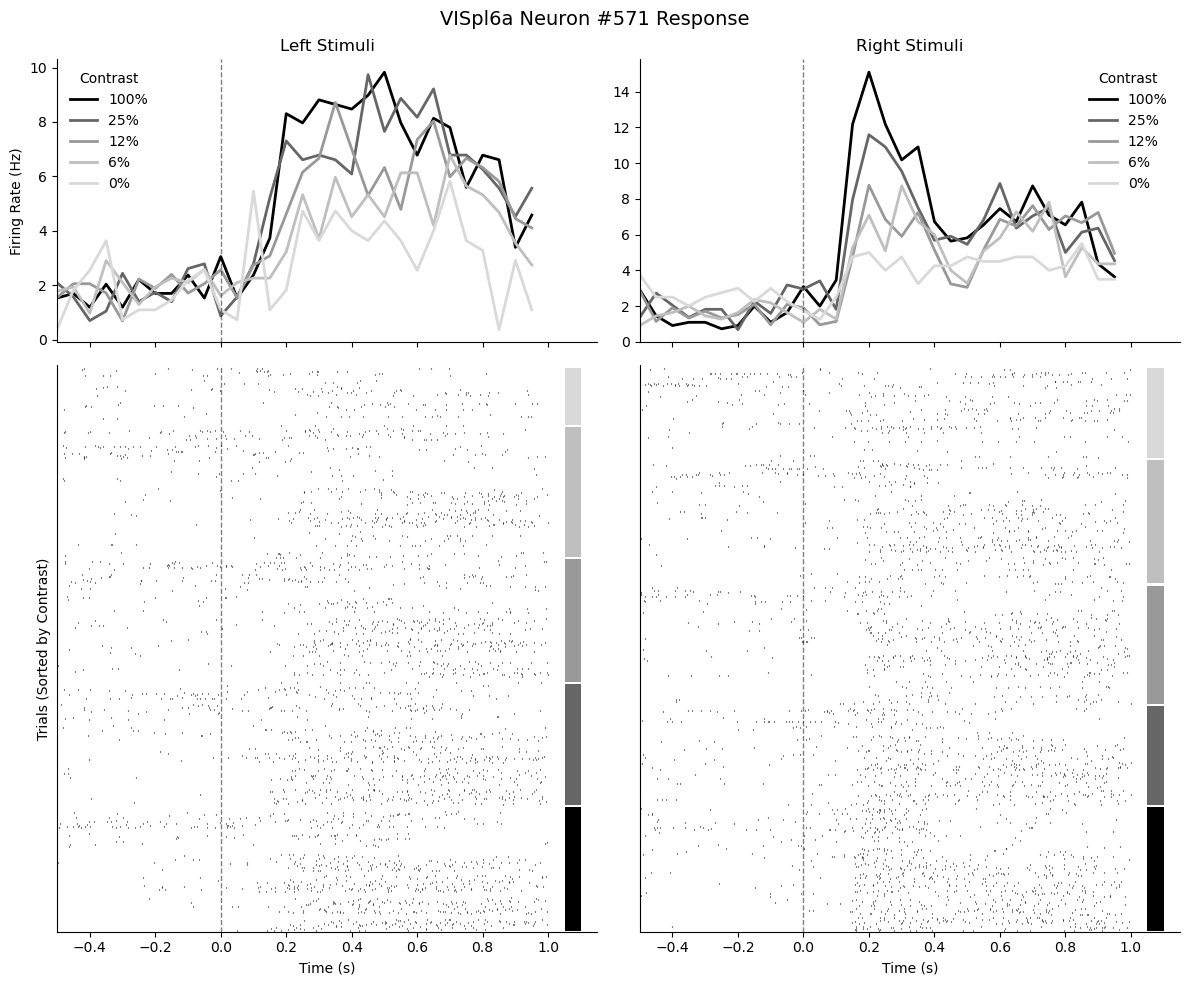

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from brainbox.population.decode import get_spike_counts_in_bins
from brainbox.processing import bincount2D

# ==========================================
# CONFIGURATION
# ==========================================
CONFIG = {
    'NEURON_TO_PLOT': 656,            # Index N: The N-th neuron in the VISp list to analyze
    'RASTER_WINDOW_PRE': 0.5,       # Seconds before Stim On
    'RASTER_WINDOW_POST': 1.0,      # Seconds after Stim On
    'BIN_SIZE': 0.05,               # Bin size for PSTH (s)
}

# ==========================================
# 1. IDENTIFY VISp NEURONS
# ==========================================
try:
    # Filter for any acronym starting with 'VISp'
    visp_mask = np.char.startswith(clusters.acronym.astype(str), 'VISp')
    visp_neuron_ids = np.where(visp_mask)[0]
    
    if len(visp_neuron_ids) == 0:
        raise ValueError("No neurons found in VISp. Check clusters.acronym.")
        
    print(f"Found {len(visp_neuron_ids)} neurons in VISp.")
    
    # Select the specific neuron requested (by index in the VISp list)
    neuron_idx = CONFIG['NEURON_TO_PLOT']
    if neuron_idx >= len(visp_neuron_ids):
        print(f"Neuron index {neuron_idx} out of range. Defaulting to 0.")
        target_cluster_id = visp_neuron_ids[0]
    else:
        target_cluster_id = visp_neuron_ids[neuron_idx]
        
    # Get the specific region acronym for this neuron (e.g., VISp, VISp2/3)
    target_acronym = clusters.acronym[target_cluster_id]
    print(f"Analyzing Cluster ID: {target_cluster_id} from Region: {target_acronym}")

except AttributeError:
    print("Error: clusters.acronym not found or incomplete data.")
    target_cluster_id = clusters.ids[0]
    target_acronym = "Unknown"

# ==========================================
# 2. MAIN LOGIC & PLOTTING (No Functions)
# ==========================================

# Initialize Figure
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, gridspec_kw={'height_ratios': [1, 2]})
# axes[0,0]: PSTH Left, axes[0,1]: PSTH Right
# axes[1,0]: Raster Left, axes[1,1]: Raster Right

# Get spikes for the target neuron only
neuron_spikes = spikes.times[spikes.clusters == target_cluster_id]

# Define Contrast Levels and associated Grayscale colors
# (1.0 = Black, 0.0625 = Light Gray)
contrasts_to_plot = [1.0, 0.25, 0.125, 0.0625, 0.0]
contrast_colors = {
    1.0:    (0.0, 0.0, 0.0, 1.0),   # Black
    0.5:    (0.2, 0.2, 0.2, 1.0),
    0.25:   (0.4, 0.4, 0.4, 1.0),
    0.125:  (0.6, 0.6, 0.6, 1.0),
    0.0625: (0.75, 0.75, 0.75, 1.0), # Light Gray
    0.0:    (0.85, 0.85, 0.85, 1.0)  # Very Light Gray for 0%
}

# Loop over sides: Left (idx 0) and Right (idx 1)
sides = ['Left', 'Right']
for col_idx, side in enumerate(sides):
    
    ax_psth = axes[0, col_idx]
    ax_rast = axes[1, col_idx]
    
    # Keep track of where we are on the Y-axis for the raster
    current_raster_y = 0
    
    # Iterate through contrasts (High to Low typically looks better or specified order)
    for cont in contrasts_to_plot:
        
        # -------------------------------------------------
        # A. Filter Trials
        # -------------------------------------------------
        # Use sl.trials as requested
        if side == 'Left':
            contrast_arr = sl.trials.contrastLeft
        else:
            contrast_arr = sl.trials.contrastRight
            
        # Create mask: matches contrast AND has valid stimOn time
        mask = (contrast_arr == cont) & (~np.isnan(sl.trials.stimOn_times))
        
        # Get event times
        events = sl.trials.stimOn_times[mask]
        
        if len(events) == 0:
            continue
            
        # Plot ALL trials found (removed slicing limit)
        events_raster = events
        
        # -------------------------------------------------
        # B. PSTH Calculation (Average Firing Rate)
        # -------------------------------------------------
        # Collect all spikes relative to all events for PSTH
        psth_spikes_concat = []
        
        for event_t in events:
            t_start = event_t - CONFIG['RASTER_WINDOW_PRE']
            t_end = event_t + CONFIG['RASTER_WINDOW_POST']
            
            # Extract spikes in window
            in_window = neuron_spikes[(neuron_spikes >= t_start) & (neuron_spikes <= t_end)]
            psth_spikes_concat.append(in_window - event_t)
            
        # Histogram
        psth_bins = np.arange(-CONFIG['RASTER_WINDOW_PRE'], 
                              CONFIG['RASTER_WINDOW_POST'] + CONFIG['BIN_SIZE'], 
                              CONFIG['BIN_SIZE'])
        
        if len(psth_spikes_concat) > 0:
            all_spikes = np.concatenate(psth_spikes_concat)
            counts, _ = np.histogram(all_spikes, bins=psth_bins)
            # Normalize: counts / num_trials / bin_size = Hz
            firing_rate = counts / len(events) / CONFIG['BIN_SIZE']
        else:
            firing_rate = np.zeros(len(psth_bins)-1)
            
        # Plot PSTH Line
        # Color based on contrast
        color_val = contrast_colors.get(cont, (0,0,0,1))
        # Label for legend
        label_text = f'{cont*100:.0f}%' if cont > 0 else '0%'
        ax_psth.plot(psth_bins[:-1], firing_rate, color=color_val, linewidth=2, label=label_text)

        # -------------------------------------------------
        # C. Raster Calculation (Individual Trials)
        # -------------------------------------------------
        # Record start Y for the "colorbar"
        block_start_y = current_raster_y
        
        for event_t in events_raster:
            t_start = event_t - CONFIG['RASTER_WINDOW_PRE']
            t_end = event_t + CONFIG['RASTER_WINDOW_POST']
            
            trial_spikes = neuron_spikes[(neuron_spikes >= t_start) & (neuron_spikes <= t_end)]
            aligned_spikes = trial_spikes - event_t
            
            # Plot Spikes - ALL BLACK as requested
            # utilizing vlines for efficiency
            ax_rast.vlines(aligned_spikes, current_raster_y - 0.4, current_raster_y + 0.4, 
                           colors='black', linewidth=0.8)
            
            current_raster_y += 1
            
        # -------------------------------------------------
        # D. Add "Colorbar" Strip for this block
        # -------------------------------------------------
        # Draw a rectangle on the right side of the plot covering these rows
        # x-coord: slightly past the window end
        bar_x = CONFIG['RASTER_WINDOW_POST'] + 0.05
        bar_width = 0.05
        bar_height = current_raster_y - block_start_y
        
        rect = patches.Rectangle((bar_x, block_start_y), bar_width, bar_height, 
                                 linewidth=0, facecolor=color_val, clip_on=False)
        ax_rast.add_patch(rect)
        
        # Add a small gap between contrast blocks
        current_raster_y += 2

    # -------------------------------------------------
    # E. Formatting per Column
    # -------------------------------------------------
    ax_psth.set_title(f'{side} Stimuli')
    ax_psth.axvline(0, color='k', linestyle='--', linewidth=1, alpha=0.5)
    ax_rast.axvline(0, color='k', linestyle='--', linewidth=1, alpha=0.5)
    
    # Add Legend to PSTH
    ax_psth.legend(frameon=False, title='Contrast')

    # Hide top/right spines
    ax_psth.spines['top'].set_visible(False)
    ax_psth.spines['right'].set_visible(False)
    ax_rast.spines['top'].set_visible(False)
    ax_rast.spines['right'].set_visible(False)
    
    # Remove y-ticks on raster if dense
    ax_rast.set_yticks([])
    
    # Limits
    ax_rast.set_xlim(-CONFIG['RASTER_WINDOW_PRE'], CONFIG['RASTER_WINDOW_POST'] + 0.15) # Extra space for bar
    ax_rast.set_ylim(-1, current_raster_y)

# Labels
axes[0, 0].set_ylabel('Firing Rate (Hz)')
axes[1, 0].set_ylabel('Trials (Sorted by Contrast)')
axes[1, 0].set_xlabel('Time (s)')
axes[1, 1].set_xlabel('Time (s)')

# Set global title with Region and Cluster ID
plt.suptitle(f'{target_acronym} Neuron #{target_cluster_id} Response', fontsize=14)
plt.tight_layout()
plt.show()